# Fase 3: CNN Propia (MEJORADA)
## Sistema Inteligente para la Detección de Tumores Cerebrales en MRI

Arquitectura CNN mejorada: 4 bloques convolucionales (2 conv + BN + ReLU + MaxPool por bloque)
con dropout reducido y he_normal initialization.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sys.path.append(os.path.abspath(".."))
from src.utils.config import (
    TRAINING_DIR, TESTING_DIR, CLASSES,
    IMG_SIZE, BATCH_SIZE, EPOCHS, MODELS_DIR
)
from src.data.loader import load_image_paths, load_and_preprocess_image
from src.data.preprocessing import encode_labels, split_dataset
from src.data.augmentation import get_tf_generators
from src.models.cnn_custom import build_cnn_custom
from src.models.train import train_model
from src.evaluation.metrics import evaluate_model
from src.evaluation.plots import plot_training_history, plot_confusion_matrix, plot_per_class_metrics

PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DOCS_DIR = os.path.join(PROJECT_DIR, 'docs')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

%matplotlib inline

In [2]:
print("Cargando Training (entrenamiento + validación)...")
train_paths, train_labels = load_image_paths(TRAINING_DIR)
X_train_full = []
y_train_full = []
for path, label in zip(train_paths, train_labels):
    img = load_and_preprocess_image(path, IMG_SIZE)
    if img is not None:
        X_train_full.append(img)
        y_train_full.append(label)
X_train_full = np.array(X_train_full)
y_train_full = encode_labels(np.array(y_train_full))
print(f"Training cargado: {X_train_full.shape}")
print(f"Distribución: {np.bincount(y_train_full)}")

print("\nCargando Testing (evaluación final)...")
test_paths, test_labels = load_image_paths(TESTING_DIR)
X_test_final = []
y_test_final = []
for path, label in zip(test_paths, test_labels):
    img = load_and_preprocess_image(path, IMG_SIZE)
    if img is not None:
        X_test_final.append(img)
        y_test_final.append(label)
X_test_final = np.array(X_test_final)
y_test_final = encode_labels(np.array(y_test_final))
print(f"Testing cargado: {X_test_final.shape}")
print(f"Distribución: {np.bincount(y_test_final)}")

Cargando Training (entrenamiento + validación)...
Training cargado: (5600, 128, 128, 1)
Distribución: [1400 1400 1400 1400]

Cargando Testing (evaluación final)...
Testing cargado: (1600, 128, 128, 1)
Distribución: [400 400 400 400]


In [3]:
X_train, X_val, _, y_train, y_val, _ = split_dataset(X_train_full, y_train_full)
train_ds, val_ds, _ = get_tf_generators(
    X_train, X_val, X_test_final, y_train, y_val, y_test_final
)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test final: {X_test_final.shape[0]}")

Train: 3920, Val: 840, Test final: 1600


In [4]:
model = build_cnn_custom()
model.summary()

try:
    tf.keras.utils.plot_model(model, os.path.join(MODELS_DIR, 'cnn_custom_architecture.png'), show_shapes=True)
except Exception as e:
    print(f"[WARNING] No se pudo generar el diagrama del modelo (requiere GraphViz): {e}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             

 Total params: 322,276 (1.23 MB)

 Trainable params: 321,380 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
history = train_model(model, train_ds, val_ds, epochs=EPOCHS, train_size=len(X_train))

⚠️  Sobrescribiendo modelo existente: c:\Users\EDUARDO\Downloads\ML PROYECTO GRUPO 3\models\cnn_custom.keras
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4343 - loss: 1.6969 
Epoch 1: val_accuracy improved from None to 0.25000, saving model to c:\Users\EDUARDO\Downloads\ML PROYECTO GRUPO 3\models\cnn_custom.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 374s 11s/step - accuracy: 0.5332 - loss: 1.3134 - val_accuracy: 0.2500 - val_loss: 8.3991
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6435 - loss: 1.0053 
Epoch 2: val_accuracy improved from 0.25000 to 0.26071, saving model to c:\Users\EDUARDO\Downloads\ML PROYECTO GRUPO 3\models\cnn_custom.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 355s 11s/step - accuracy: 0.6467 - loss: 1.0013 - val_accuracy: 0.2607 - val_loss: 2.3998
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6696 - loss: 0.9348 
Epoch 3: val_accuracy improved from 0.26071 to 0.28095, saving model to c:\Users\EDUARDO\Downloads\ML PROYECTO GRUPO 3\

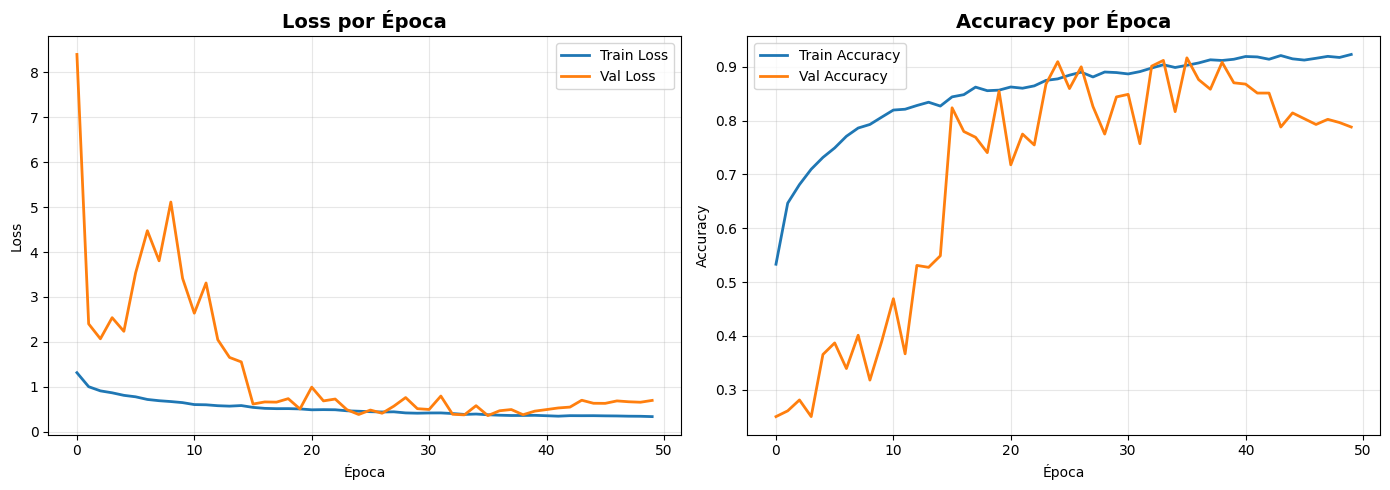

In [6]:
plot_training_history(history, os.path.join(DOCS_DIR, 'cnn_propia_curvas.png'))

In [7]:
global_metrics, per_class, cm = evaluate_model(model, X_test_final, y_test_final)

print("=" * 60)
print("MÉTRICAS GLOBALES")
print(f"Accuracy:  {global_metrics['accuracy']:.4f}")
print(f"Precision: {global_metrics['precision']:.4f}")
print(f"Recall:    {global_metrics['recall']:.4f}")
print(f"F1-Score:  {global_metrics['f1_score']:.4f}")

print("\nMÉTRICAS POR CLASE")
for cls, metrics in per_class.items():
    print(f"{cls:>12}: Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}, F1={metrics['f1_score']:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step
MÉTRICAS GLOBALES
Accuracy:  0.7925
Precision: 0.8221
Recall:    0.7925
F1-Score:  0.7880

MÉTRICAS POR CLASE
      glioma: Precision=0.9828, Recall=0.5725, F1=0.7235
  meningioma: Precision=0.6825, Recall=0.7200, F1=0.7007
     notumor: Precision=0.7153, Recall=0.9925, F1=0.8314
   pituitary: Precision=0.9077, Recall=0.8850, F1=0.8962


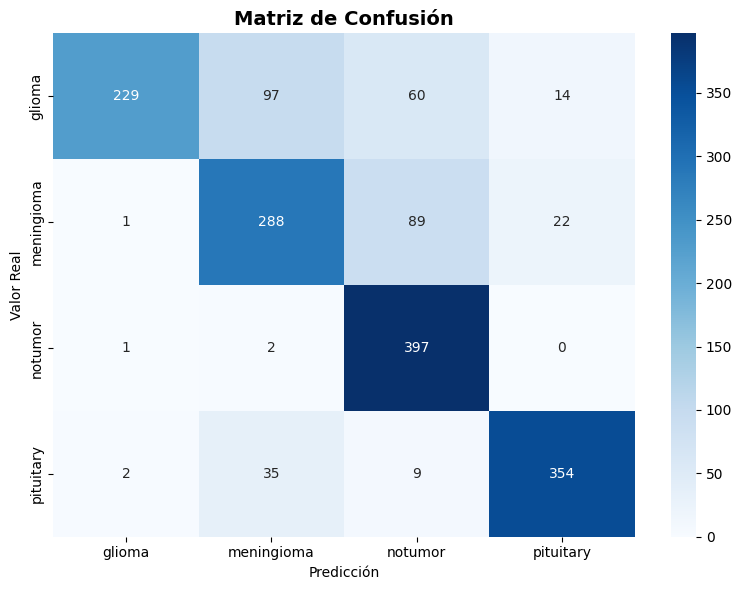

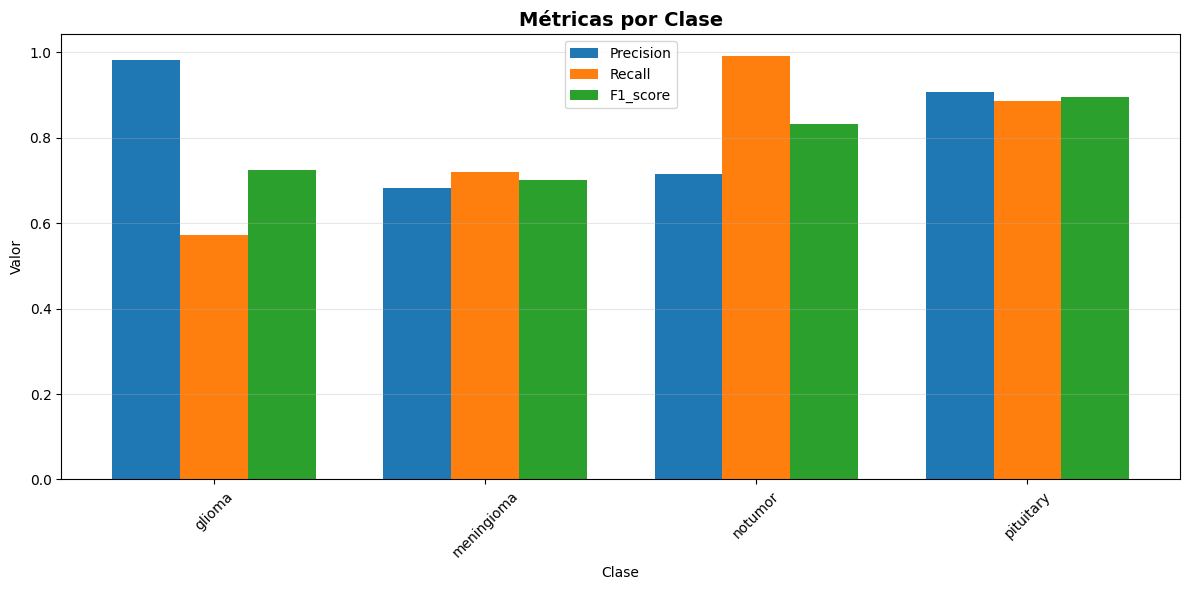

In [8]:
plot_confusion_matrix(cm, os.path.join(DOCS_DIR, 'cnn_propia_confusion.png'))
plot_per_class_metrics(per_class, os.path.join(DOCS_DIR, 'cnn_propia_metrics.png'))

In [9]:
model_path = os.path.join(MODELS_DIR, 'cnn_custom.keras')
if os.path.exists(model_path):
    os.remove(model_path)
    print(f"♻️  Sobrescribiendo {model_path}...")
model.save(model_path)
print(f"✅ Modelo guardado en {model_path}")

♻️  Sobrescribiendo c:\Users\EDUARDO\Downloads\ML PROYECTO GRUPO 3\models\cnn_custom.keras...
✅ Modelo guardado en c:\Users\EDUARDO\Downloads\ML PROYECTO GRUPO 3\models\cnn_custom.keras
